In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset
df = pd.read_csv('../data/raw/train_revised.csv')

# Vistazo inicial
print("Shape:", df.shape)
print("Columnas:", df.columns.tolist())
print("\nPrimeras filas:")
df.head()

C:\Users\Victus\AppData\Local\Temp\ipykernel_81592\689741196.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Shape: (51645, 10)
Columnas: ['ride_id', 'seat_number', 'payment_method', 'payment_receipt', 'travel_date', 'travel_time', 'travel_from', 'travel_to', 'car_type', 'max_capacity']

Primeras filas:


,ride_id,seat_number,payment_method,payment_receipt,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity
0,1442,15A,Mpesa,UZUEHCBUSO,17-10-17,7:15,Migori,Nairobi,Bus,49
1,5437,14A,Mpesa,TIHLBUSGTE,19-11-17,7:12,Migori,Nairobi,Bus,49
2,5710,8B,Mpesa,EQX8Q5G19O,26-11-17,7:05,Keroka,Nairobi,Bus,49
3,5777,19A,Mpesa,SGP18CL0ME,27-11-17,7:10,Homa Bay,Nairobi,Bus,49
4,5778,11A,Mpesa,BM97HFRGL9,27-11-17,7:12,Migori,Nairobi,Bus,49


In [4]:
print("=== TIPOS DE DATOS ===")
print(df.dtypes)

print("\n=== VALORES NULOS ===")
print(df.isnull().sum())

print("\n=== ESTADÍSTICAS BÁSICAS ===")
df.describe()

=== TIPOS DE DATOS ===
ride_id             int64
seat_number        object
payment_method     object
payment_receipt    object
travel_date        object
travel_time        object
travel_from        object
travel_to          object
car_type           object
max_capacity        int64
dtype: object

=== VALORES NULOS ===
ride_id            0
seat_number        0
payment_method     0
payment_receipt    0
travel_date        0
travel_time        0
travel_from        0
travel_to          0
car_type           0
max_capacity       0
dtype: int64

=== ESTADÍSTICAS BÁSICAS ===


,ride_id,max_capacity
count,51645.000000,51645.000000
mean,10188.645793,34.534321
std,2211.295708,18.451193
min,1442.000000,11.000000
25%,8287.000000,11.000000
50%,10353.000000,49.000000
75%,12029.000000,49.000000
max,20117.000000,49.000000


In [5]:
print("=== RUTAS DE ORIGEN (travel_from) ===")
print(df['travel_from'].value_counts())

print("\n=== DESTINOS (travel_to) ===")
print(df['travel_to'].value_counts())

print("\n=== TIPO DE VEHÍCULO (car_type) ===")
print(df['car_type'].value_counts())

print("\n=== MÉTODO DE PAGO ===")
print(df['payment_method'].value_counts())

=== RUTAS DE ORIGEN (travel_from) ===
travel_from
Kisii        22607
Migori        7027
Homa Bay      6304
Sirare        4449
Rongo         3928
Kehancha      1909
Awendo        1788
Kijauri       1031
Keroka         988
Nyachenge      512
Rodi           405
Mbita          378
Ndhiwa         236
Sori            55
Keumbu          22
Oyugis           5
Kendu Bay        1
Name: count, dtype: int64

=== DESTINOS (travel_to) ===
travel_to
Nairobi    51645
Name: count, dtype: int64

=== TIPO DE VEHÍCULO (car_type) ===
car_type
Bus        31985
shuttle    19660
Name: count, dtype: int64

=== MÉTODO DE PAGO ===
payment_method
Mpesa    51532
Cash       113
Name: count, dtype: int64


In [6]:
# Convertir travel_date a datetime
df['travel_date'] = pd.to_datetime(df['travel_date'])

print("Rango de fechas:")
print("Desde:", df['travel_date'].min())
print("Hasta:", df['travel_date'].max())
print("Total días:", (df['travel_date'].max() - df['travel_date'].min()).days)

Rango de fechas:
Desde: 2017-01-12 00:00:00
Hasta: 2018-12-04 00:00:00
Total días: 691


C:\Users\Victus\AppData\Local\Temp\ipykernel_81592\3897920549.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['travel_date'] = pd.to_datetime(df['travel_date'])


In [7]:
# Corregir parsing de fecha con formato explícito
df['travel_date'] = pd.to_datetime(df['travel_date'], dayfirst=True)

# VARIABLE OBJETIVO: número de tickets vendidos por viaje (ride_id) por día
demanda = df.groupby(['travel_date', 'travel_from', 'travel_to', 'car_type']).agg(
    tickets_vendidos=('seat_number', 'count'),
    capacidad_max=('max_capacity', 'first')
).reset_index()

print("Shape demanda agregada:", demanda.shape)
print("\nPrimeras filas:")
demanda.head(10)

Shape demanda agregada: (1526, 6)

Primeras filas:


,travel_date,travel_from,travel_to,car_type,tickets_vendidos,capacidad_max
0,2017-01-12,Keroka,Nairobi,shuttle,106,11
1,2017-01-12,Keumbu,Nairobi,shuttle,1,11
2,2017-01-12,Kisii,Nairobi,Bus,9,49
3,2017-01-12,Kisii,Nairobi,shuttle,306,11
4,2017-01-12,Migori,Nairobi,Bus,1,49
5,2017-01-12,Rongo,Nairobi,Bus,11,49
6,2017-02-12,Keroka,Nairobi,Bus,3,49
7,2017-02-12,Keumbu,Nairobi,shuttle,1,11
8,2017-02-12,Kisii,Nairobi,Bus,26,49
9,2017-02-12,Kisii,Nairobi,shuttle,26,11


In [8]:
print("=== TICKETS VENDIDOS POR RUTA (travel_from) ===")
resumen = demanda.groupby('travel_from')['tickets_vendidos'].agg(['sum','mean','max']).round(2)
resumen.columns = ['Total tickets', 'Promedio por día', 'Máximo en un día']
print(resumen.sort_values('Total tickets', ascending=False))

=== TICKETS VENDIDOS POR RUTA (travel_from) ===
             Total tickets  Promedio por día  Máximo en un día
travel_from                                                   
Kisii                22607             79.60               494
Migori                7027             49.49               238
Homa Bay              6304             46.35                85
Sirare                4449             42.37                85
Rongo                 3928             27.86                70
Kehancha              1909             20.09                45
Awendo                1788             22.35                62
Kijauri               1031              4.82                23
Keroka                 988              6.14               190
Nyachenge              512              5.22                18
Rodi                   405             25.31                39
Mbita                  378             31.50                56
Ndhiwa                 236             19.67                24
Sori   

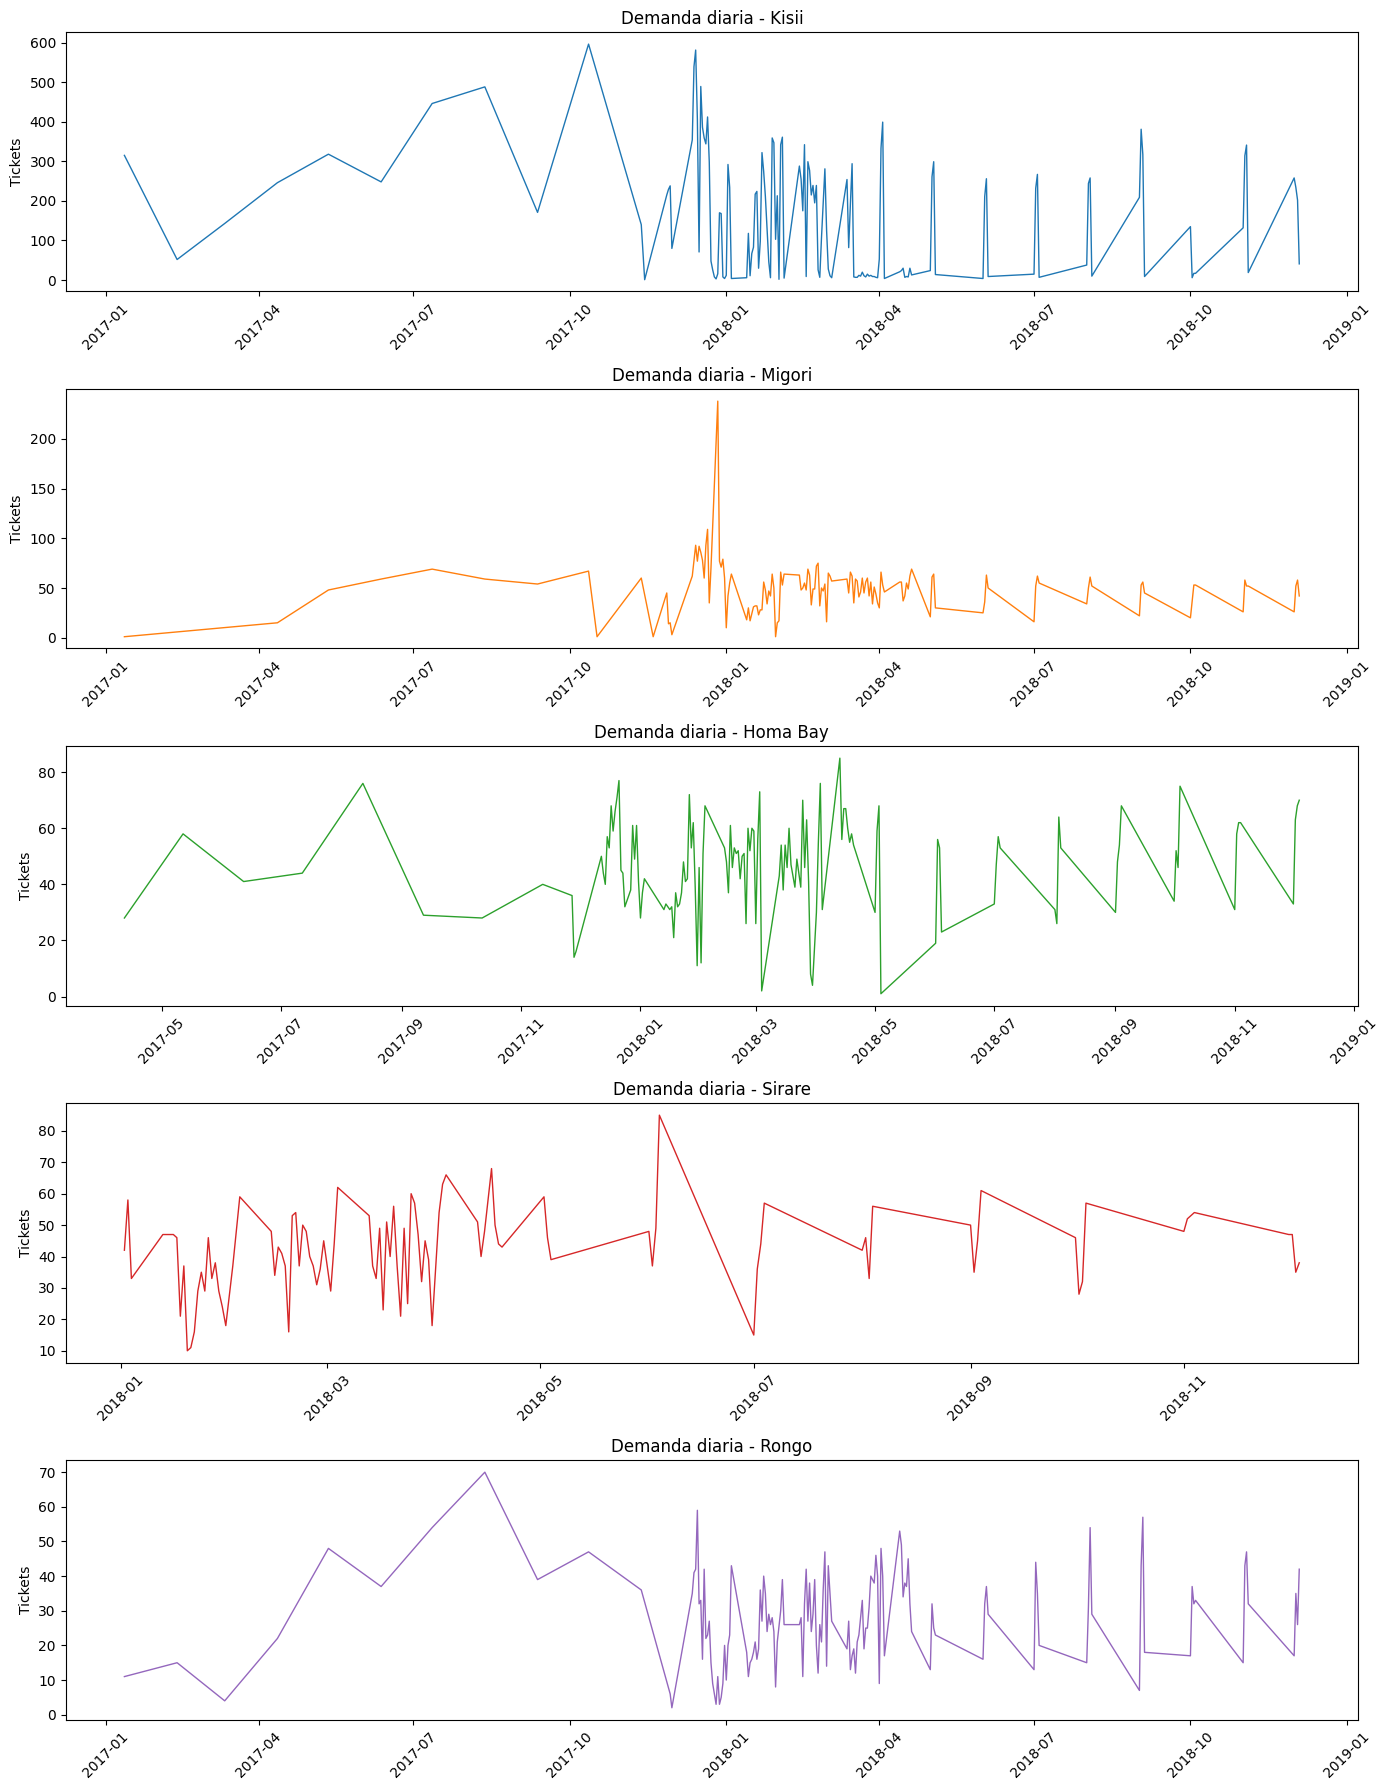

Gráfica guardada!


In [9]:
rutas_principales = ['Kisii', 'Migori', 'Homa Bay', 'Sirare', 'Rongo']

fig, axes = plt.subplots(5, 1, figsize=(14, 18))

for i, ruta in enumerate(rutas_principales):
    datos_ruta = demanda[demanda['travel_from'] == ruta].groupby('travel_date')['tickets_vendidos'].sum()
    axes[i].plot(datos_ruta.index, datos_ruta.values, linewidth=1, color=f'C{i}')
    axes[i].set_title(f'Demanda diaria - {ruta}')
    axes[i].set_ylabel('Tickets')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/demanda_por_ruta.png', dpi=150)
plt.show()
print("Gráfica guardada!")

In [10]:
# Filtrar solo rutas principales y agregar por fecha y ruta
demanda_procesada = demanda[demanda['travel_from'].isin(rutas_principales)].copy()

# Agrupar por fecha y ruta (uniendo Bus + shuttle)
demanda_procesada = demanda_procesada.groupby(
    ['travel_date', 'travel_from']
)['tickets_vendidos'].sum().reset_index()

# Guardar
demanda_procesada.to_csv('../data/processed/demanda_diaria.csv', index=False)

print("Shape final:", demanda_procesada.shape)
print("\nRango de fechas por ruta:")
print(demanda_procesada.groupby('travel_from')['travel_date'].agg(['min','max','count']))

Shape final: (669, 3)

Rango de fechas por ruta:
                   min        max  count
travel_from                             
Homa Bay    2017-04-12 2018-12-04    136
Kisii       2017-01-12 2018-12-04    145
Migori      2017-01-12 2018-12-04    142
Rongo       2017-01-12 2018-12-04    141
Sirare      2018-01-02 2018-12-04    105


In [11]:
# Crear índice de fechas completo para cada ruta
rutas = demanda_procesada['travel_from'].unique()
fecha_min = demanda_procesada['travel_date'].min()
fecha_max = demanda_procesada['travel_date'].max()

# Crear todas las combinaciones fecha x ruta
fechas_completas = pd.date_range(start=fecha_min, end=fecha_max, freq='D')
indice_completo = pd.MultiIndex.from_product(
    [fechas_completas, rutas], 
    names=['travel_date', 'travel_from']
)

# Reindexar y rellenar huecos con 0
demanda_continua = (
    demanda_procesada
    .set_index(['travel_date', 'travel_from'])
    .reindex(indice_completo, fill_value=0)
    .reset_index()
)

print("Shape antes:", demanda_procesada.shape)
print("Shape después (serie continua):", demanda_continua.shape)
print("\nVerificación - días por ruta:")
print(demanda_continua.groupby('travel_from')['tickets_vendidos'].agg(['count','sum','mean']).round(2))

Shape antes: (669, 3)
Shape después (serie continua): (3460, 3)

Verificación - días por ruta:
             count    sum   mean
travel_from                     
Homa Bay       692   6304   9.11
Kisii          692  22607  32.67
Migori         692   7027  10.15
Rongo          692   3928   5.68
Sirare         692   4449   6.43


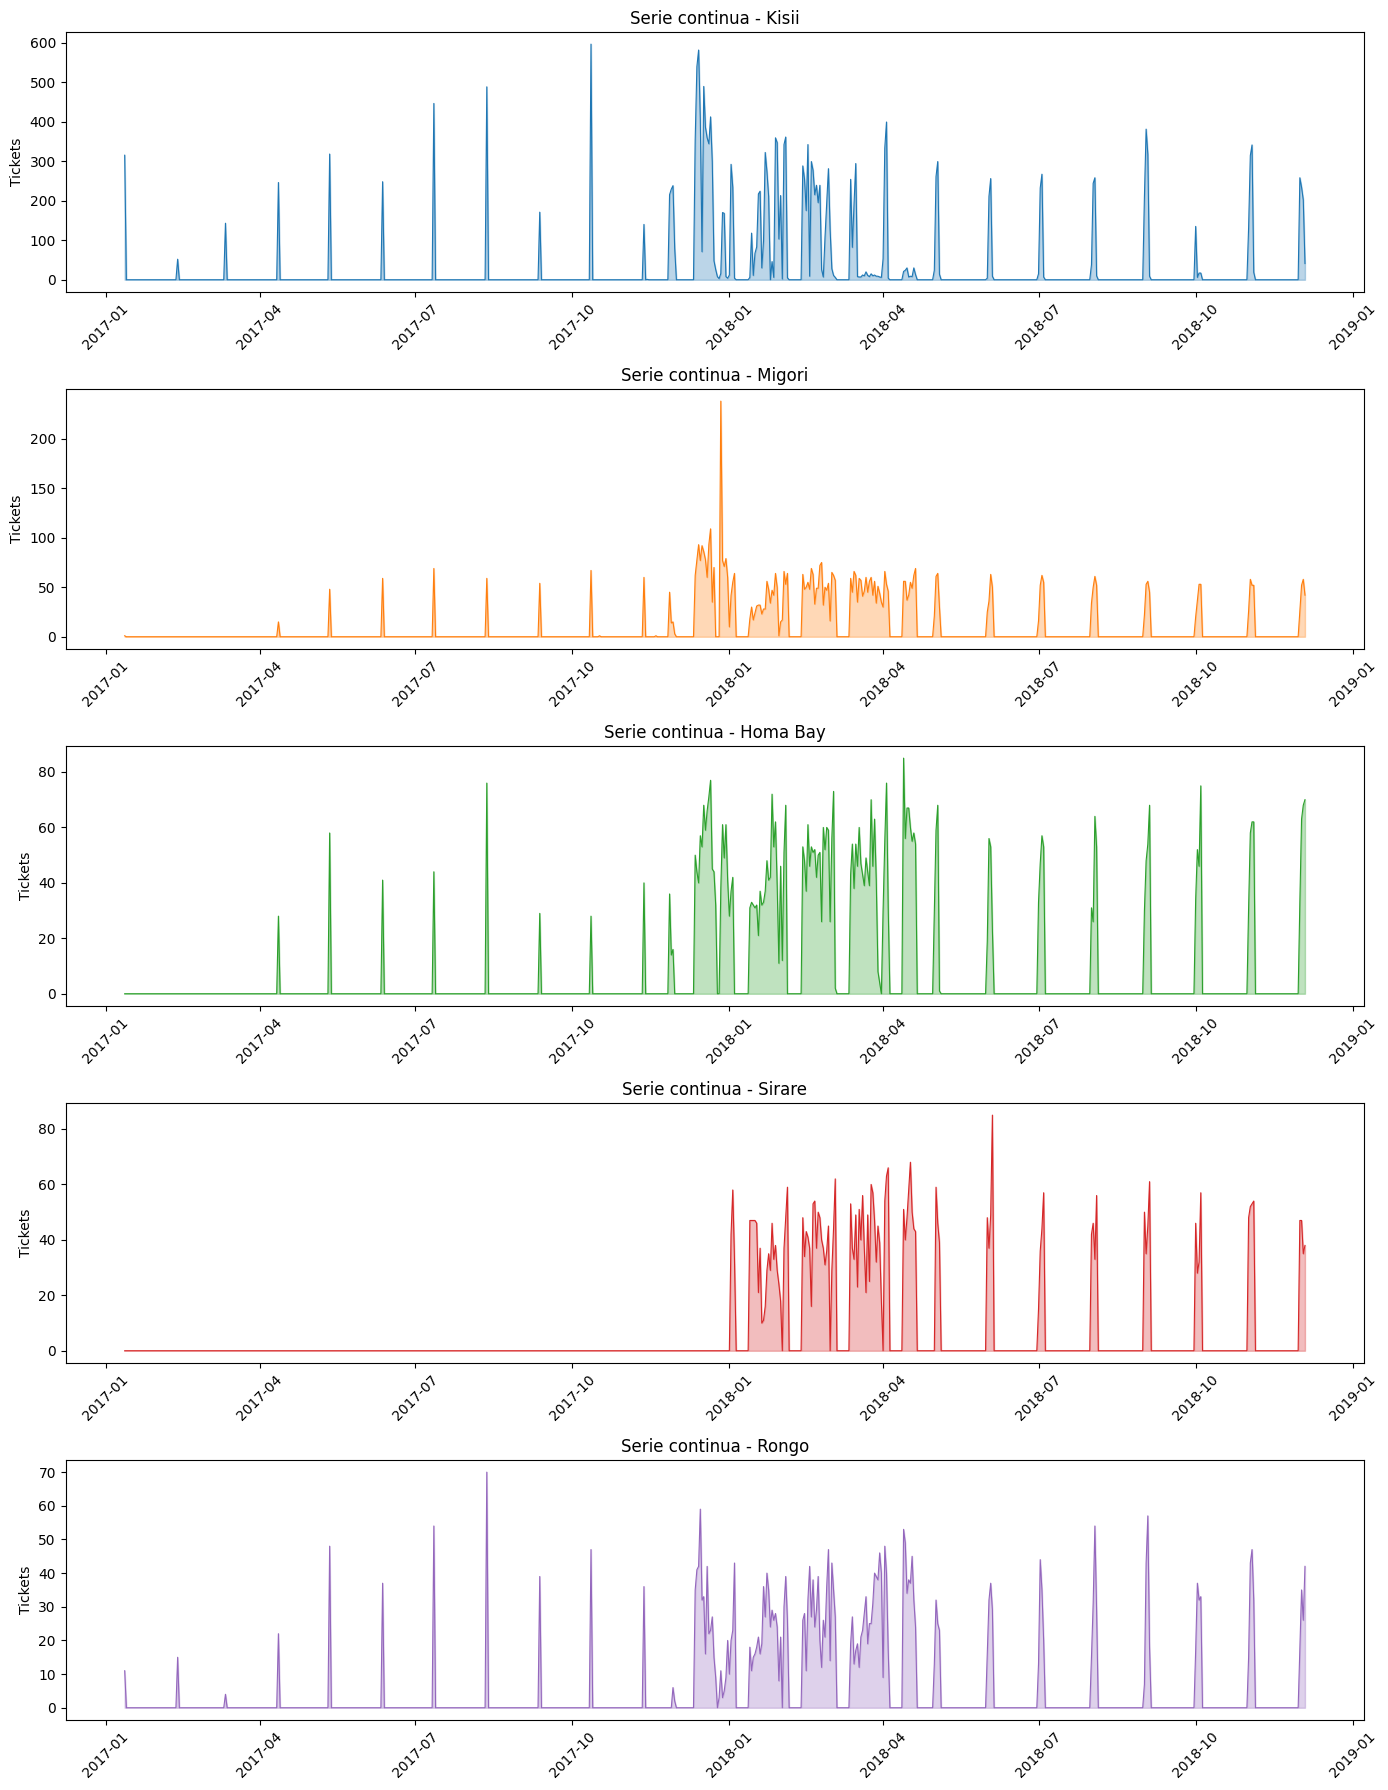

In [12]:
fig, axes = plt.subplots(5, 1, figsize=(14, 18))

for i, ruta in enumerate(rutas_principales):
    datos = demanda_continua[demanda_continua['travel_from'] == ruta]
    axes[i].plot(datos['travel_date'], datos['tickets_vendidos'], 
                 linewidth=0.8, color=f'C{i}')
    axes[i].fill_between(datos['travel_date'], datos['tickets_vendidos'], 
                         alpha=0.3, color=f'C{i}')
    axes[i].set_title(f'Serie continua - {ruta}')
    axes[i].set_ylabel('Tickets')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/series_continuas.png', dpi=150)
plt.show()

In [13]:
demanda_continua.to_csv('../data/processed/demanda_continua.csv', index=False)
print("✓ Serie continua guardada")
print("\nResumen final del EDA:")
print(f"  - Rutas analizadas: {demanda_continua['travel_from'].nunique()}")
print(f"  - Período: {fecha_min.date()} → {fecha_max.date()}")
print(f"  - Total días por ruta: {len(fechas_completas)}")
print(f"  - Total registros: {demanda_continua.shape[0]}")

✓ Serie continua guardada

Resumen final del EDA:
  - Rutas analizadas: 5
  - Período: 2017-01-12 → 2018-12-04
  - Total días por ruta: 692
  - Total registros: 3460


In [14]:
# Recargar datos originales procesados (sin los ceros)
demanda_semanal = demanda_procesada.copy()
demanda_semanal['semana'] = demanda_semanal['travel_date'].dt.to_period('W').apply(lambda r: r.start_time)

demanda_semanal = demanda_semanal.groupby(
    ['semana', 'travel_from']
)['tickets_vendidos'].sum().reset_index()

print("Shape semanal:", demanda_semanal.shape)
print("\nSemanas por ruta:")
print(demanda_semanal.groupby('travel_from')['semana'].count())

Shape semanal: (188, 3)

Semanas por ruta:
travel_from
Homa Bay    38
Kisii       42
Migori      41
Rongo       41
Sirare      26
Name: semana, dtype: int64


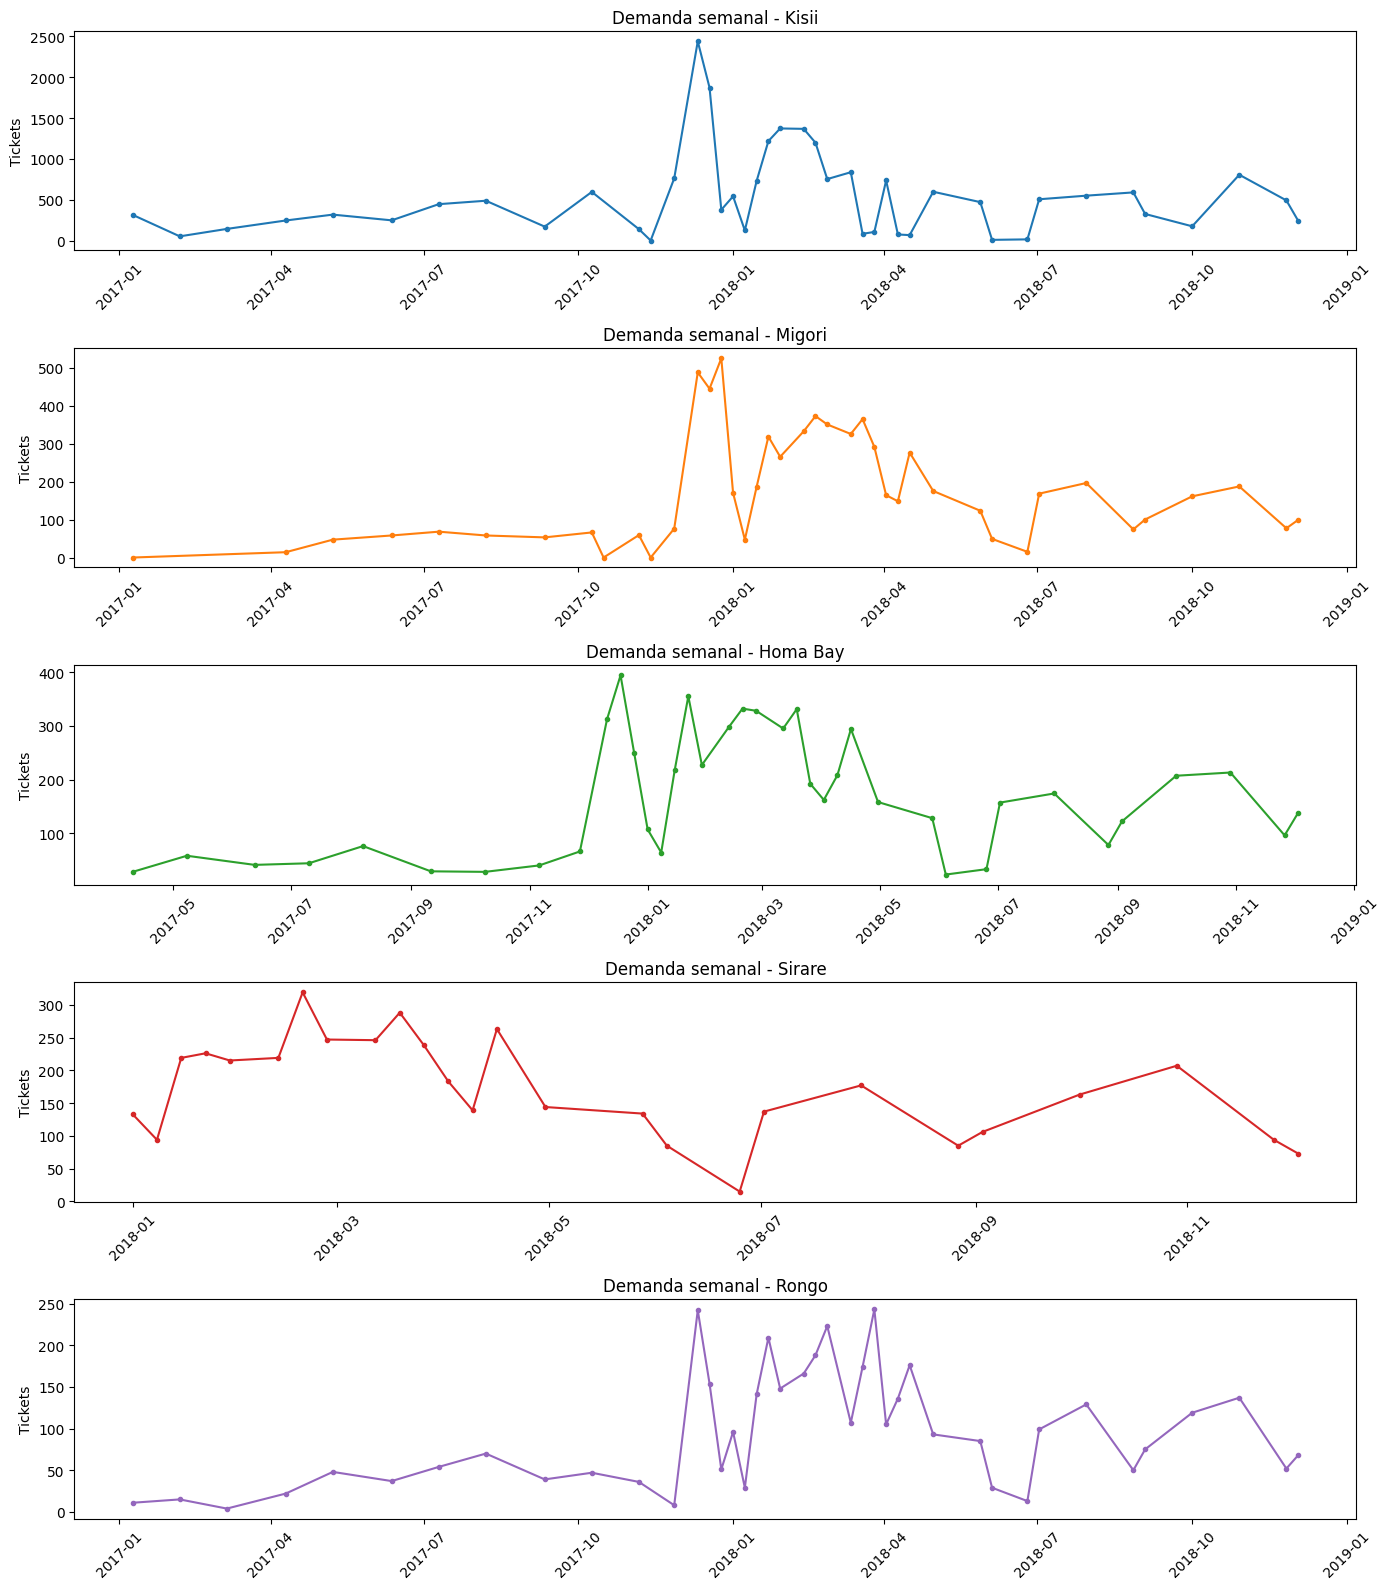

In [15]:
fig, axes = plt.subplots(5, 1, figsize=(14, 16))

for i, ruta in enumerate(rutas_principales):
    datos = demanda_semanal[demanda_semanal['travel_from'] == ruta]
    axes[i].plot(datos['semana'], datos['tickets_vendidos'],
                 marker='o', markersize=3, linewidth=1.5, color=f'C{i}')
    axes[i].set_title(f'Demanda semanal - {ruta}')
    axes[i].set_ylabel('Tickets')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/demanda_semanal.png', dpi=150)
plt.show()

In [ ]:
demanda_semanal.to_csv('../data/processed/demanda_semanal.csv', index=False)
print("✓ Datos semanales guardados")
print("\nEstadísticas finales por ruta:")
print(demanda_semanal.groupby('travel_from')['tickets_vendidos'].agg(['min','max','mean','std']).round(2))